In [4]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [36]:
from __future__ import annotations
from dataclasses import dataclass
from enum import Enum, auto
from typing import List, Sequence, Tuple, Optional
import random
import math


# --- 返り値・イベント定義 ----------------------------------------------------

class Network:
    N: int
    k_ave: float
    edge_list: List[int]
    address_list: List[int]
    cursor_list: List[int]

    def __init__(self, N, k_ave, edge_list, address_list, cursor_list):
        self.N = N
        self.k_ave = k_ave
        self.edge_list = edge_list
        self.address_list = address_list
        self.cursor_list = cursor_list

    def get_neighbors(self, node_index: int) -> List[int]:
        return self.edge_list[self.address_list[node_index]:self.cursor_list[node_index]]

def nx_to_network(G: nx.Graph) -> Network:
    N = G.number_of_nodes()
    k_ave = 2 * G.number_of_edges() / N
    print(f"N = {N}, k_ave = {k_ave}")

    address_list = np.zeros(N, dtype=int)
    cursor_list = np.zeros(N, dtype=int)
    for i in range(N-1):
        deg = len(list(G.neighbors(i)))
        address_list[i + 1] = address_list[i] + deg
        cursor_list[i] = address_list[i + 1]

    cursor_list[N-1] = cursor_list[N-2] + len(list(G.neighbors(N-1)))

    edge_list = np.zeros(2 * G.number_of_edges(), dtype=int)

    for i in range(N):
        for jidx, j in enumerate(list(G.neighbors(i))):
            edge_list[address_list[i] + jidx] = j

    return Network(N, k_ave, edge_list, address_list, cursor_list)

class SISEventType(Enum):
    INITIAL_INFECTION = auto()
    INFECTION = auto()
    RECOVERY = auto()


@dataclass(frozen=True)
class SISEvent:
    t: float
    type: SISEventType
    node: int


@dataclass(frozen=True)
class ContinuousRunResult:
    I: List[int]          # 各時刻ステップの感染者数 I(t)
    events: List[SISEvent]  # 逐次イベント列


# --- ユーティリティ ----------------------------------------------------------


def _total_rate(network, state: np.ndarray, infected_neighbors_num: np.ndarray, lam: float, gamma: float, c: float) -> float:
    """全発火率（感染＋回復）。Java 実装と同じロジック。"""
    lamb_rate = lam * (1 - state) * infected_neighbors_num
    gamma_rate = state * gamma / (c * infected_neighbors_num + 1)
    total = lamb_rate.sum() + gamma_rate.sum()
    return total


# --- メイン：連続時間 SIS シミュレーション（イベント記録付き） -------------

def simulate_continuous_with_events(
    network,
    lam: float,              # λ: 感染率（エッジ単位）
    gamma: float,            # γ: 回復率の基準
    rho0: float,             # 初期感染率（0〜1）
    tmax: float,             # 観測終了時刻（連続時間）
    c: float,                # 回復率の調整係数（γ/(c*k_inf+1))
    rng: Optional[random.Random] = None,
) -> ContinuousRunResult:
    """
    Java版 ContinuousSIS.simulateContinuousWithEvents と同等の挙動。
    返り値: ContinuousRunResult(I(t), dt, events)
    """
    rng = rng or random.Random()

    I: List[int] = []

    infected_neighbors_num = np.zeros(network.N, dtype=int)

    # 状態配列：0=Susceptible, 1=Infected
    state = np.zeros(network.N, dtype=int)
    times = []
    # events: List[SISEvent] = []

    # 初期感染者数の決定（Java と同じ丸め規則）
    initial_infected_num = int(network.N * rho0)
    if rho0 == 0.0:
        initial_infected_num = 0
    elif initial_infected_num == 0 and rho0 > 0.0:
        initial_infected_num = 1

    # シャッフルして先頭から初期感染に設定
    node_indices = list(range(network.N))
    rng.shuffle(node_indices)
    for i in range(initial_infected_num):
        u = node_indices[i]
        state[u] = 1
        # events.append(SISEvent(0.0, SISEventType.INITIAL_INFECTION, u))
        neighbors = network.get_neighbors(u)
        for n in neighbors:
            infected_neighbors_num[n] += 1

    I.append(initial_infected_num)
    times.append(0.0)

    current_time = 0.0
    current_infected = initial_infected_num

    # 連続時間シミュレーション（Gillespie）
    while current_time < tmax and current_infected > 0:
        total_rate = _total_rate(network, state, infected_neighbors_num, lam, gamma, c)
        if total_rate <= 0.0:
            break

        # 次イベントまでの待ち時間 ~ Exp(total_rate)
        u = rng.random()
        time_to_next = -math.log(u) / total_rate
        current_time += time_to_next

        # どのイベントが起こるかを累積率で決定（Java と同じ順序）
        r = rng.random() * total_rate
        cum = 0.0
        fired = False

        # 感染イベント候補：S の各ノードについて λ*k_inf
        for i in range(network.N):
            if state[i] == 0:
                k_inf = infected_neighbors_num[i]
                if k_inf > 0:
                    cum += lam * k_inf
                    if r <= cum:
                        state[i] = 1
                        current_infected += 1
                        neighbors = network.get_neighbors(i)
                        for n in neighbors:
                            infected_neighbors_num[n] += 1
                        I.append(current_infected)
                        times.append(current_time)
                        # events.append(SISEvent(current_time, SISEventType.INFECTION, i))
                        fired = True
                        break

        # 回復イベント候補：I の各ノードについて γ/(c*k_inf+1)
        if not fired:
            for i in range(network.N):
                if state[i] == 1:
                    k_inf = infected_neighbors_num[i]
                    cum += gamma / (c * k_inf + 1.0)
                    if r <= cum:
                        state[i] = 0
                        current_infected -= 1
                        neighbors = network.get_neighbors(i)
                        for n in neighbors:
                            infected_neighbors_num[n] -= 1
                        I.append(current_infected)
                        times.append(current_time)
                        # events.append(SISEvent(current_time, SISEventType.RECOVERY, i))
                        break

    I = np.array(I)
    times = np.array(times)
    return I, times


# 簡単な動作チェック（小さな完全グラフ）
N = 4000
k_ave = 6
G = nx.random_regular_graph(k_ave, N)
network = nx_to_network(G)

I, times = simulate_continuous_with_events(
    network=network,
    lam=1.2,
    gamma=1.0,
    rho0=1.0 / N,
    tmax=5.0,
    c=0.5,
    rng=random.Random(0),
)

print("len(I) =", len(I), "events =", len(times))
# 先頭の数点とイベント先頭だけ表示
print("I[:10] =", I[:10])
print("first events:", times[:3])


N = 4000, k_ave = 6.0
len(I) = 10509 events = 10509
I[:10] = [ 1  2  3  4  5  6  7  8  9 10]
first events: [0.         0.22670295 0.35993541]


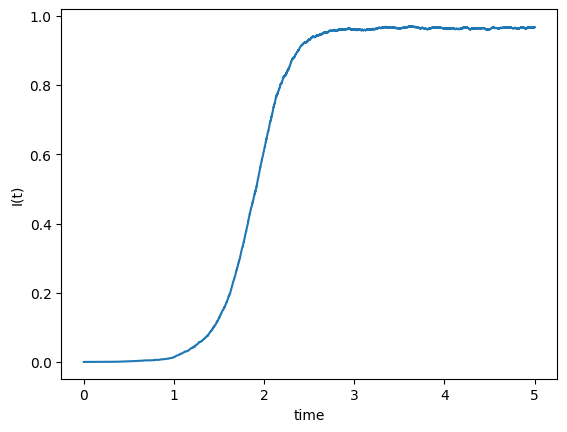

In [38]:
import matplotlib.pyplot as plt

plt.plot(times, I/N)
plt.xlabel("time")
plt.ylabel("I(t)")
plt.show()

In [ ]:
# 簡単な動作チェック（小さな完全グラフ）
N = 4000
k_ave = 6
itr = 10
G = nx.random_regular_graph(k_ave, N)
network = nx_to_network(G)

c_list = [0.0, 0.5, 1.0, 1.5]
dlamb = 0.1
lamb_values = np.arange(0.0, 2.0 + dlamb, dlamb)


shape = (len(c_list), len(lamb_values), itr)
I_all = np.zeros(shape, dtype=object)
times_all = np.zeros(shape, dtype=object)

for c_idx, c in enumerate(c_list):
    for lamb_idx, lamb in enumerate(lamb_values):
        for itr_idx in range(itr):
            I, times = simulate_continuous_with_events(
                network=network,
                lam=lamb,
                gamma=1.0,
                rho0=1.0 / N,
                tmax=5.0,
                c=c,
                rng=random.Random(0),
            )
            I_all[c_idx, lamb_idx, itr_idx] = I
            times_all[c_idx, lamb_idx, itr_idx] = times

In [39]:
import os
import random
import numpy as np
import networkx as nx
import multiprocessing as mp

# ===== ワーカー初期化（各プロセスで一度だけ呼ばれる） =====
def _init_worker(net):
    # 各プロセスにネットワークをグローバルに配る（1回だけシリアライズ）
    global NETWORK
    NETWORK = net

# ===== ワーカー本体 =====
def _run_one(args):
    c_idx, lamb_idx, itr_idx, c, lamb, base_seed, N = args
    seed = base_seed + itr_idx + 10_000 * lamb_idx + 1_000_000 * c_idx
    rng = random.Random(seed)
    # NETWORK は _init_worker でセットされたものを使う
    I, times = simulate_continuous_with_events(
        network=NETWORK,
        lam=lamb,
        gamma=1.0,
        rho0=1.0 / N,
        tmax=5.0,
        c=c,
        rng=rng,
    )
    return (c_idx, lamb_idx, itr_idx, I, times)

if __name__ == "__main__":
    # ==== 既存のセットアップ ====
    N = 4000
    k_ave = 6
    itr = 10
    G = nx.random_regular_graph(k_ave, N)
    network = nx_to_network(G)

    c_list = [0.0, 0.5, 1.0, 1.5]
    dlamb = 0.1
    lamb_values = np.arange(0.0, 2.0 + dlamb, dlamb)

    # ==== タスク列挙 ====
    base_seed = 0
    tasks = []
    for c_idx, c in enumerate(c_list):
        for lamb_idx, lamb in enumerate(lamb_values):
            for itr_idx in range(itr):
                tasks.append((c_idx, lamb_idx, itr_idx, c, lamb, base_seed, N))

    # ==== 並列実行（macはspawn。明示しておく） ====
    ctx = mp.get_context("spawn")
    procs = os.cpu_count() or 1
    # 過剰なIPCを避ける軽いチャンク設定
    chunksize = max(1, len(tasks) // (procs * 4))

    with ctx.Pool(
        processes=procs,
        initializer=_init_worker,
        initargs=(network,),
        maxtasksperchild=None,  # 長時間なら数千で区切るのも可
    ) as pool:
        results = pool.map(_run_one, tasks, chunksize=chunksize)

    # ==== 受け皿に格納 ====
    shape = (len(c_list), len(lamb_values), itr)
    I_all = np.empty(shape, dtype=object)
    times_all = np.empty(shape, dtype=object)

    for c_idx, lamb_idx, itr_idx, I, times in results:
        I_all[c_idx, lamb_idx, itr_idx] = I
        times_all[c_idx, lamb_idx, itr_idx] = times

    # ==== .npz 保存（圧縮） ====
    np.savez_compressed(
        "simulation_results.npz",
        I_all=I_all,
        times_all=times_all,
        c_list=np.array(c_list, dtype=float),
        lamb_values=lamb_values,
        N=N,
        k_ave=k_ave,
        itr=itr,
        dlamb=dlamb,
    )
    print("Saved to simulation_results.npz")


N = 4000, k_ave = 6.0


Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/black/.pyenv/versions/3.12.3/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/black/.pyenv/versions/3.12.3/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute '_init_worker' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


KeyboardInterrupt: 